# Notebook 02: Exploratory Data Analysis & Visualization
## Volkswagen Stock Data 2000–2025

This notebook explores the cleaned VW stock dataset through summary statistics 
and visualizations. The goal is to identify trends, patterns, anomalies, and 
key events in VW's 25-year trading history.

*Input:* data/processed/vw_stock_features.csv  
*Output:* Charts saved to output/ folder

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Chart styling — run this once and all charts inherit it
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('Blues_d')

print('Libraries loaded successfully.')

Libraries loaded successfully.


In [12]:
df = pd.read_csv(r'C:\vw_project\data\processed\vw_stock_features.csv',
                 index_col='Date',
                 parse_dates=True)

print('Shape:', df.shape)
print('Date range:', df.index.min().date(), 'to', df.index.max().date())
print('Columns:', df.columns.tolist())

Shape: (6684, 25)
Date range: 2000-01-03 to 2026-02-26
Columns: ['Open', 'High', 'Low', 'Close', 'Volume', 'Daily_Return_Pct', 'Daily_Range', 'MA_20', 'MA_50', 'MA_200', 'EMA_12', 'EMA_26', 'MACD', 'MACD_Signal', 'BB_Upper', 'BB_Lower', 'BB_Width', 'RSI_14', 'Volume_MA_20', 'Cumulative_Return_Pct', 'Year', 'Month', 'Quarter', 'Day_of_Week', 'Volatility_30d']


In [13]:
df.describe().round(2)

,Open,High,Low,Close,Volume,Daily_Return_Pct,Daily_Range,MA_20,MA_50,MA_200,...,BB_Upper,BB_Lower,BB_Width,RSI_14,Volume_MA_20,Cumulative_Return_Pct,Year,Month,Quarter,Volatility_30d
count,6684.00,6684.00,6684.00,6684.00,6684.00,6684.00,6684.00,6684.00,6684.00,6684.00,...,6684.00,6684.00,6684.00,6684.00,6684.00,6684.00,6684.00,6684.00,6684.00,6655.00
mean,124.96,126.81,123.05,124.91,921909.36,0.04,3.77,124.84,124.72,124.23,...,134.64,115.04,19.59,50.98,914903.52,617.47,2012.52,6.47,2.49,2.12
std,66.23,68.00,64.71,66.22,1584179.54,2.90,6.79,65.73,65.23,62.82,...,74.79,58.76,28.50,17.92,1314443.66,380.36,7.57,3.44,1.12,2.00
min,28.80,29.86,28.06,28.66,10727.00,-22.66,0.00,30.67,31.47,34.06,...,32.60,27.87,0.98,1.60,24681.25,64.62,2000.00,1.00,1.00,0.68
25%,59.83,60.76,59.33,60.24,66679.00,-1.07,1.54,59.10,57.62,55.65,...,63.69,55.85,7.65,37.63,73885.15,245.99,2006.00,3.00,1.00,1.39
50%,128.00,129.66,125.95,127.70,138624.00,0.00,2.59,127.77,128.55,130.24,...,136.14,116.89,13.11,50.88,133303.05,633.51,2012.00,7.00,3.00,1.78
75%,164.56,166.60,162.65,164.52,1473518.75,1.13,4.15,164.48,165.03,161.83,...,174.92,153.33,21.90,64.01,1769835.99,845.03,2019.00,9.00,3.00,2.25
max,520.00,635.00,491.00,520.00,18590532.00,146.62,310.01,415.96,347.29,281.04,...,580.77,304.17,413.75,99.20,10614055.25,2886.87,2026.00,12.00,4.00,28.64


## Section 1: Price History
The most fundamental question in stock analysis: what did the price actually do?
We start broad (full 25-year history) then zoom into specific periods.

In [14]:
import os
os.makedirs(r'C:\vw_project\output', exist_ok=True)
print('Output folder ready.')

Output folder ready.


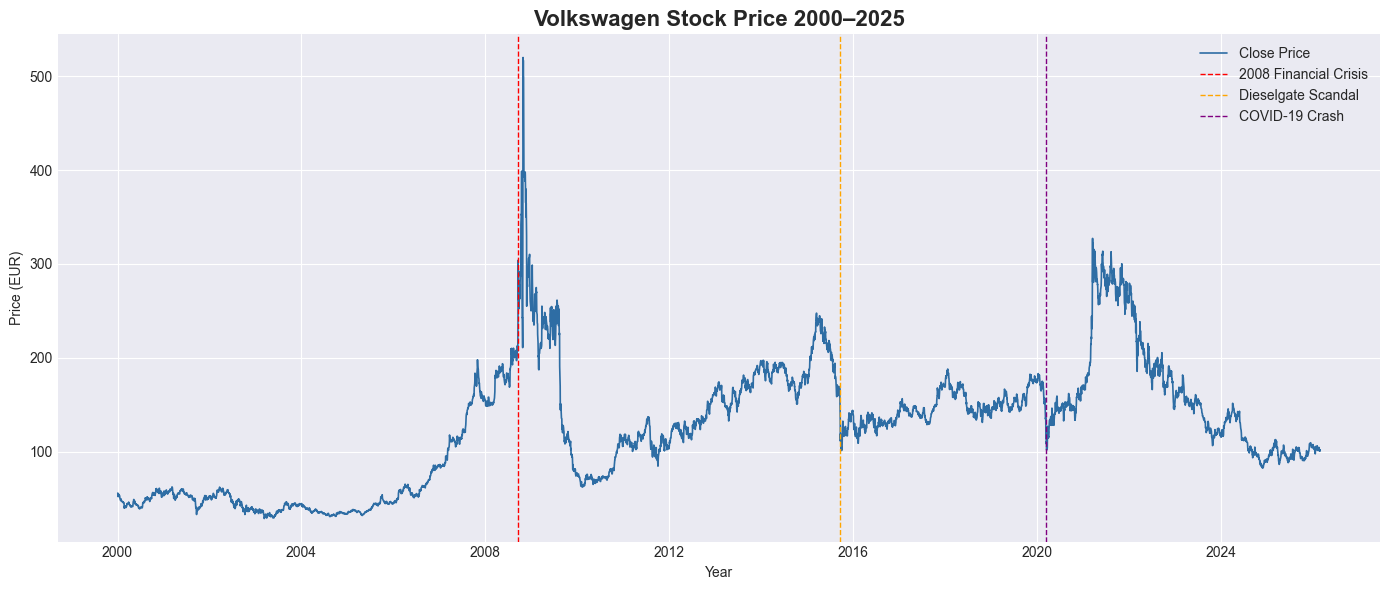

In [15]:
fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(df.index, df['Close'], 
        color='#2E6DA4', 
        linewidth=1.2, 
        label='Close Price')


ax.axvline(pd.Timestamp('2008-09-15'), color='red',    
           linestyle='--', linewidth=1, label='2008 Financial Crisis')
ax.axvline(pd.Timestamp('2015-09-18'), color='orange', 
           linestyle='--', linewidth=1, label='Dieselgate Scandal')
ax.axvline(pd.Timestamp('2020-03-16'), color='purple', 
           linestyle='--', linewidth=1, label='COVID-19 Crash')

ax.set_title('Volkswagen Stock Price 2000–2025', fontsize=16, fontweight='bold')
ax.set_xlabel('Year')
ax.set_ylabel('Price (EUR)')
ax.legend()

plt.tight_layout()
plt.savefig(r'C:\vw_project\output\01_full_price_history.png', dpi=150)
plt.show()

## Chart 1: Volkswagen Stock Price 2000–2025

### What This Chart Shows
A complete 25 year view of VW's closing price with three major events marked.

### Key Observations

- **2000–2007:** Slow steady climb from ~€50 to ~€200, reflecting the global 
  economic boom of the early 2000s

- **2008 Porsche Short Squeeze:** Price spiked violently to €520 — briefly making 
  VW the most valuable company in the world — before collapsing almost immediately

- **2008 Financial Crisis:** Sharp drop to ~€70 as the global economy contracted

- **2009–2015:** Strong recovery back to ~€250, interrupted abruptly by the 
  Dieselgate scandal (September 2015) which wiped ~50% off the stock in weeks

- **2020 COVID-19:** Price crashed to ~€100 before recovering sharply to €320 
  by 2021, driven by global EV investment optimism and VW's electric vehicle push

- **2022–2025:** Sustained decline back to ~€100, reflecting slowing EV sales, 
  European factory closures, and intensifying competition from Chinese manufacturers

### Key Takeaway
VW stock has returned to 2010 price levels by 2025, meaning a long-term investor 
who bought after the 2008 crash and held through 2025 made very little net gain 
over 15 years.

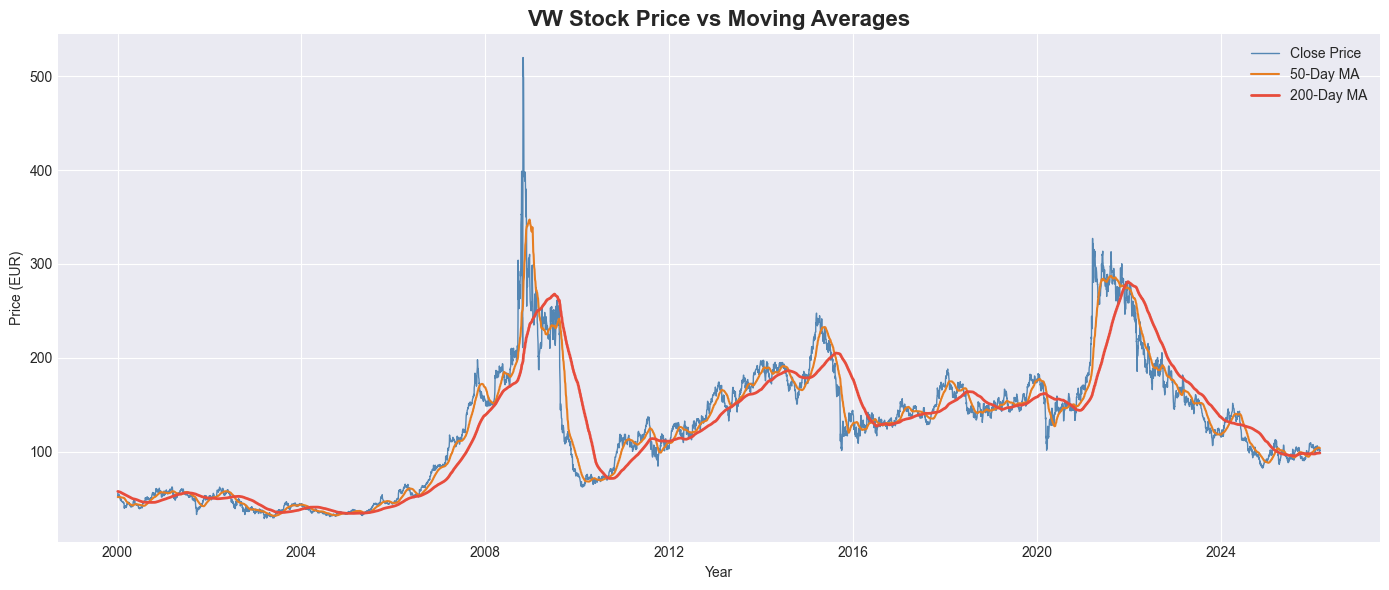

In [16]:
fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(df['Close'],  color='#2E6DA4', linewidth=1,   alpha=0.8, label='Close Price')
ax.plot(df['MA_50'],  color='#E67E22', linewidth=1.5, label='50-Day MA')
ax.plot(df['MA_200'], color='#E74C3C', linewidth=2,   label='200-Day MA')

ax.set_title('VW Stock Price vs Moving Averages', fontsize=16, fontweight='bold')
ax.set_xlabel('Year')
ax.set_ylabel('Price (EUR)')
ax.legend()

plt.tight_layout()
plt.savefig(r'C:\vw_project\output\02_moving_averages.png', dpi=150)
plt.show()

```markdown
## Chart 2: VW Stock Price vs Moving Averages (50-Day & 200-Day)

### What This Chart Shows
The closing price overlaid with two moving averages that smooth out daily noise 
and reveal the true underlying trend direction.

### How to Read This Chart
- **Blue line:** Daily closing price — reactive and noisy
- **Orange line (MA-50):** Average of last 50 trading days — short-term trend
- **Red line (MA-200):** Average of last 200 trading days — long-term trend

When the orange crosses **above** the red → Golden Cross (bullish signal)  
When the orange crosses **below** the red → Death Cross (bearish signal)

### Key Observations

- **2000–2007:** All three lines move together tightly, confirming a slow and 
  stable upward trend with very low volatility

- **2008 Porsche Squeeze:** The blue price line spikes violently to €520 while 
  the moving averages barely react — this confirms the spike was an artificial 
  anomaly, not a genuine trend

- **2008–2009 Crisis:** MA-50 crossed below MA-200 (Death Cross), correctly 
  signalling the prolonged crash that followed

- **2015 Dieselgate:** MA-50 dropped sharply below MA-200 immediately after 
  the scandal — another Death Cross confirming the downtrend was real

- **2020–2021:** MA-50 crossed above MA-200 (Golden Cross) during the post-COVID 
  recovery, correctly identifying the rally to €320

- **2022–2025:** MA-50 has crossed below MA-200 again and both lines are 
  trending downward — the current Death Cross suggests the decline is structural, 
  not temporary

### Key Takeaway
Every major crash in VW's history produced a Death Cross on this chart. 
The moving averages did not predict the crashes but confirmed them early, 
giving trend-following investors a clear exit signal each time.
```

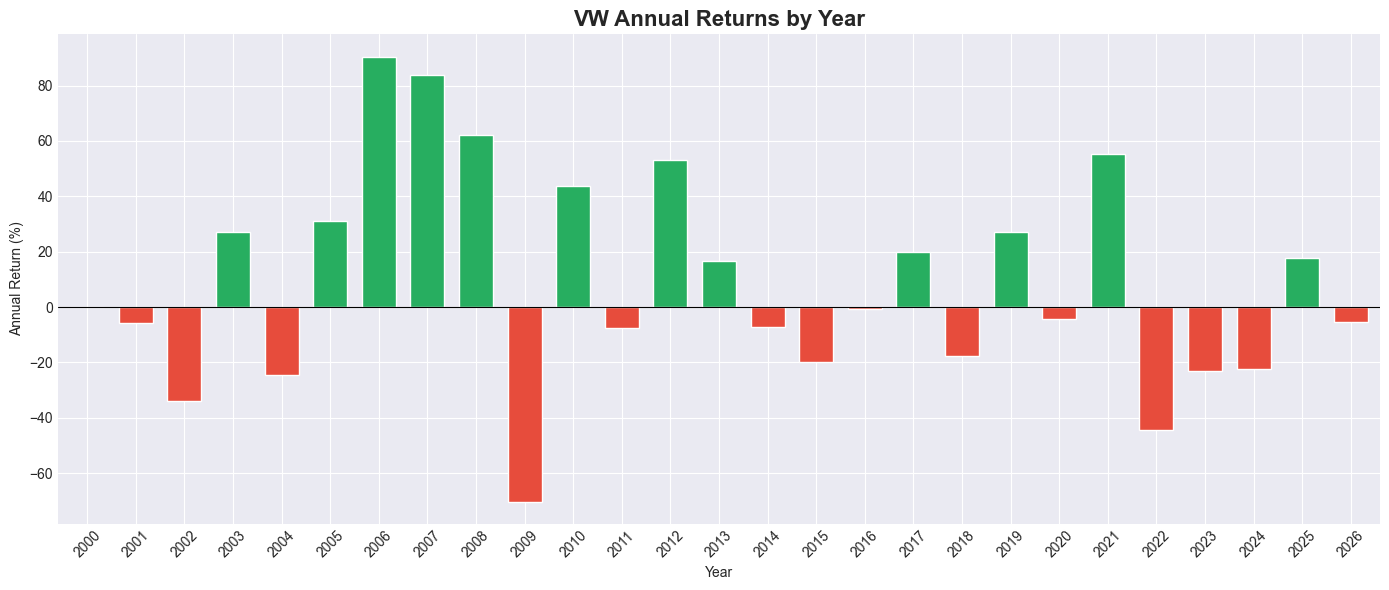

Year
2009   -70.28
2022   -44.41
2002   -33.83
2004   -24.46
2023   -23.13
2024   -22.47
2015   -20.03
2018   -17.59
2011    -7.74
2014    -7.05
2001    -5.73
2026    -5.30
2020    -4.20
2016    -0.80
2000    -0.14
2013    16.68
2025    17.83
2017    19.73
2003    27.09
2019    27.20
2005    31.01
2010    43.59
2012    53.25
2021    55.20
2008    61.99
2007    83.86
2006    90.44
Name: Return_Pct, dtype: float64


In [17]:
# Calculate return for each year
annual = df.groupby('Year')['Close'].agg(['first', 'last'])
annual['Return_Pct'] = ((annual['last'] - annual['first']) / annual['first'] * 100).round(2)

# Green bars for positive years, red for negative
colors = ['#27AE60' if x >= 0 else '#E74C3C' for x in annual['Return_Pct']]

fig, ax = plt.subplots(figsize=(14, 6))
annual['Return_Pct'].plot(kind='bar', color=colors, ax=ax, edgecolor='white', width=0.7)

ax.axhline(0, color='black', linewidth=0.8)
ax.set_title('VW Annual Returns by Year', fontsize=16, fontweight='bold')
ax.set_ylabel('Annual Return (%)')
ax.set_xlabel('Year')
ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig(r'C:\vw_project\output\03_annual_returns.png', dpi=150)
plt.show()

# Print the numbers too
print(annual['Return_Pct'].sort_values())

```markdown
## Chart 3: VW Annual Returns by Year

Green bars are years where the stock went up. Red bars are years where it went down.

### Best and Worst Years (Ranked)

Best years:
- 2006: +90% — peak of the pre-crisis boom and Porsche accumulating VW shares
- 2007: +84% — same momentum continuing into the following year
- 2021: +55% — post-COVID recovery and VW's big electric vehicle push

Worst years:
- 2009: -70% — the full weight of the global financial crisis hitting VW
- 2022: -44% — rising interest rates, energy crisis, and EV profitability fears
- 2002: -34% — dot-com bust and broader market collapse

### Key Observations

- VW had 15 positive years and 12 negative years out of 26 — more good than bad
  but the bad years tend to hurt more than the good years reward

- The three worst years (2009, 2022, 2002) all happened during major global
  economic crises, not VW-specific events

- 2015 Dieselgate only produced a -20% annual return — significant but not
  catastrophic because the stock had already started recovering by year end

- From 2022 to 2024 VW had three consecutive negative years, something that
  had not happened since the early 2000s dot-com crash

### Key Takeaway
VW's worst losses (-70%, -44%) are nearly double the size of its best gains
(+90%, +84%) when you account for the fact that a 70% loss requires a 233%
gain just to break even.
```

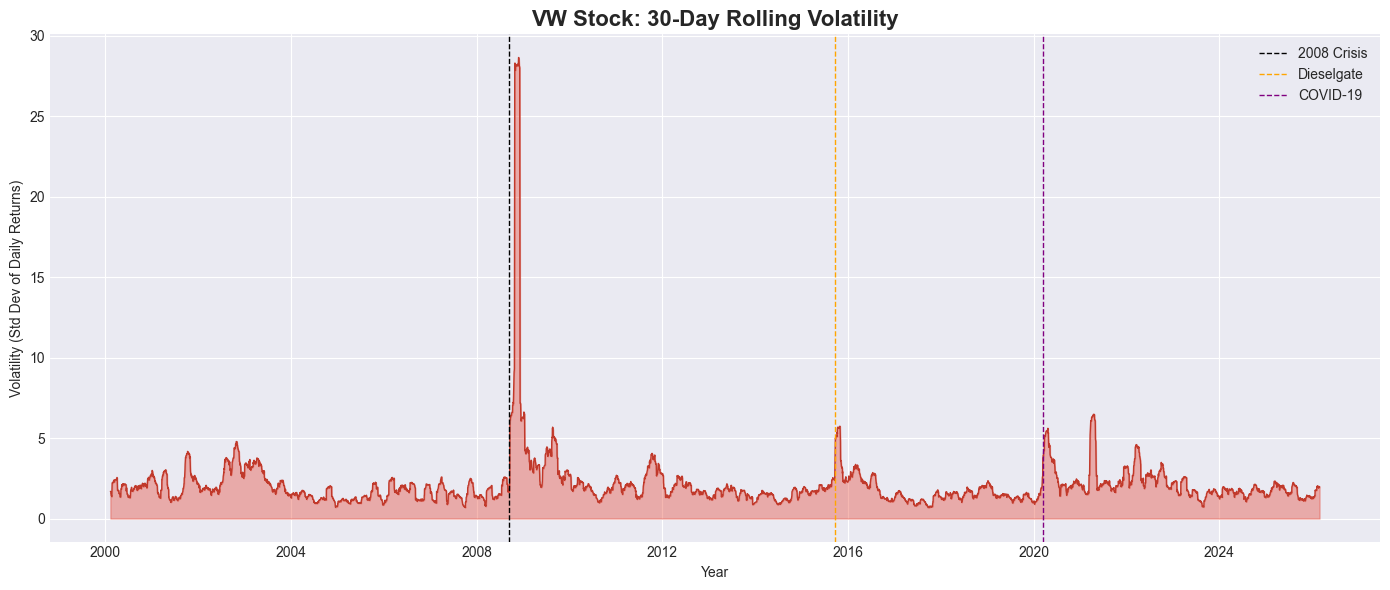

In [18]:
fig, ax = plt.subplots(figsize=(14, 6))

ax.fill_between(df.index, df['Volatility_30d'], color='#E74C3C', alpha=0.4)
ax.plot(df['Volatility_30d'], color='#C0392B', linewidth=1)

ax.axvline(pd.Timestamp('2008-09-15'), color='black',  
           linestyle='--', linewidth=1, label='2008 Crisis')
ax.axvline(pd.Timestamp('2015-09-18'), color='orange', 
           linestyle='--', linewidth=1, label='Dieselgate')
ax.axvline(pd.Timestamp('2020-03-16'), color='purple', 
           linestyle='--', linewidth=1, label='COVID-19')

ax.set_title('VW Stock: 30-Day Rolling Volatility', fontsize=16, fontweight='bold')
ax.set_ylabel('Volatility (Std Dev of Daily Returns)')
ax.set_xlabel('Year')
ax.legend()

plt.tight_layout()
plt.savefig(r'C:\vw_project\output\04_volatility.png', dpi=150)
plt.show()

## What This Chart Is Telling You

The chart measures how wildly the stock price was swinging on a day-to-day basis at any given point in time. When the red area is flat and low (around 1–2), the stock was moving calmly and predictably. When it spikes upward, the stock was moving erratically and investors were panicking.

The 2008 spike to nearly 29 is extraordinary. To put that in perspective, a normal day for VW stock moves about 1–2% in either direction. During the peak of the 2008 crisis, it was moving nearly 29% in a single day on average. That is complete chaos — nobody knew what the stock was worth from one hour to the next.

What is also interesting is how quickly volatility returned to normal after each crisis. The 2008 spike looks dramatic but within a year the red area had settled back down. Same with Dieselgate and COVID. Markets panic hard and fast, then calm down.

---

```markdown
## Chart 4: VW Stock 30-Day Rolling Volatility

This chart shows how much the stock price was jumping around at any 
given point in time. Low and flat means calm markets. Spikes mean panic.

### Key Observations

- For most of the 25 years volatility sat quietly between 1 and 3,
  meaning VW typically moved 1-3% per day in normal conditions

- The 2008 Porsche short squeeze caused a historic spike to nearly 29 —
  the stock was moving almost 29% per day, the most chaotic period
  in VW's entire recorded history

- Dieselgate (2015) and COVID-19 (2020) both produced clear spikes
  to around 5-6, roughly triple the normal level

- After every single crisis, volatility returned to normal within
  months meaning markets panic quickly but also calm down quickly

### Key Takeaway
Three events stand out clearly above all others: 2008, 2015, and 2020.
Everything else in 25 years of trading was relatively calm by comparison.
The 2008 spike was so extreme it makes the other two look minor on this scale.
```

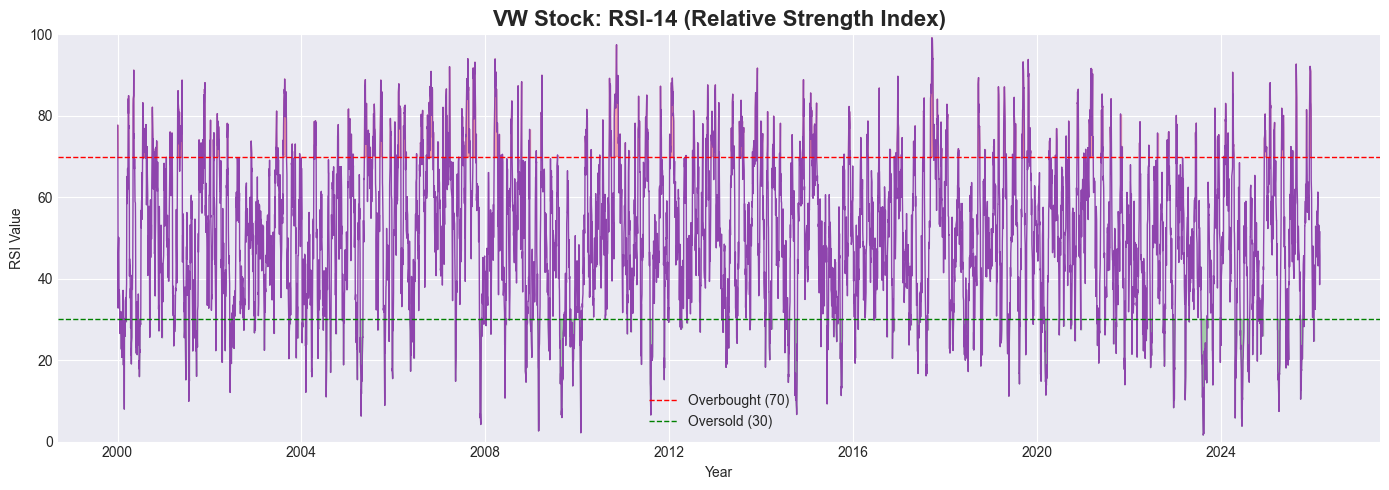

In [19]:
fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(df['RSI_14'], color='#8E44AD', linewidth=1)

# Overbought and oversold lines
ax.axhline(70, color='red',   linestyle='--', linewidth=1, label='Overbought (70)')
ax.axhline(30, color='green', linestyle='--', linewidth=1, label='Oversold (30)')
ax.fill_between(df.index, df['RSI_14'], 70, 
                where=(df['RSI_14'] >= 70), alpha=0.3, color='red')
ax.fill_between(df.index, df['RSI_14'], 30, 
                where=(df['RSI_14'] <= 30), alpha=0.3, color='green')

ax.set_title('VW Stock: RSI-14 (Relative Strength Index)', 
             fontsize=16, fontweight='bold')
ax.set_ylabel('RSI Value')
ax.set_xlabel('Year')
ax.set_ylim(0, 100)
ax.legend()

plt.tight_layout()
plt.savefig(r'C:\vw_project\output\05_rsi.png', dpi=150)
plt.show()

## What This Chart Is Telling You

RSI measures momentum — essentially asking "has this stock been going up too much or down too much recently?" It runs on a scale of 0 to 100.

Above 70 (red line) means the stock has been rising so consistently that it is considered overbought — meaning buyers have potentially pushed the price higher than it deserves and a pullback is likely soon.

Below 30 (green line) means the stock has been falling so consistently that it is considered oversold — meaning sellers have potentially pushed the price lower than it deserves and a bounce is likely soon.

What stands out immediately on your chart is how frantically the purple line moves. It is crossing above 70 and below 30 constantly throughout the entire 25 years. This tells you VW is a stock that swings between extremes regularly — it rarely sits calmly in the middle for long. That is consistent with everything we have already seen in the volatility and returns charts.

---

```markdown
## Chart 5: RSI-14 (Relative Strength Index)

RSI measures momentum on a scale of 0 to 100.
Above 70 means the stock has been rising too fast and a pullback may be coming.
Below 30 means the stock has been falling too hard and a bounce may be coming.

### Key Observations

- The RSI crosses above 70 and below 30 frequently across all 25 years,
  meaning VW regularly swings between overbought and oversold conditions
  making it rarely a calm, stable stock.

- The most extreme overbought readings (RSI above 90) occurred around
  2000, 2003, and 2008 — all periods of sharp short-term price surges
  before significant corrections followed.

- Around 2009 and 2011 the RSI touched its lowest levels, consistent
  with the stock being heavily sold off during and after the financial crisis.

- From 2022 onwards the RSI continues oscillating wildly, reflecting
  the uncertainty investors feel about VW's future direction.

### Key Takeaway
VW is not a stock that moves slowly and predictably. The RSI has been
hitting extreme levels in both directions for 25 years straight, confirming
this is a high-momentum stock where prices can move sharply in either
direction in a short period of time.
```

## EDA Summary — Key Observations

1. Price trend: VW started at around €50 in 2000 and sits at around €100 in 2025,
   but the journey was anything but straight. The stock hit €520 in 2008, crashed,
   recovered to €320 in 2021, and has been declining ever since. A long-term
   investor who held through all of this made very little net gain over 25 years.

2. Most volatile period: The 2008 Porsche short squeeze caused the single most
   extreme volatility spike in the entire dataset, reaching nearly 29 on the
   30-day rolling measure. Dieselgate (2015) and COVID-19 (2020) both caused
   secondary spikes to around 5-6 but look minor compared to 2008.

3. Best year: 2006 with +90%, followed closely by 2007 at +84%. Both were driven
   by the pre-crisis economic boom and Porsche secretly buying up VW shares,
   which artificially inflated demand.

4. Worst year: 2009 at -70%, as the full weight of the global financial crisis
   hit VW's stock price after the short squeeze collapsed. The second worst was
   2022 at -44%, driven by the energy crisis and EV profitability fears.

5. RSI insight: VW's RSI has been hitting extreme levels in both directions
   for the entire 25 years. The most extreme overbought readings above 90
   occurred around 2000, 2003, and 2008 — each time followed by a significant
   price correction. This confirms VW is a high-momentum stock that rarely
   stays calm for long.

6. Volume insight: Trading volume spiked sharply during the 2008 crisis,
   which makes sense — extreme price moves attract more buyers and sellers.
   Outside of crisis periods volume has been gradually declining since around
   2015, suggesting fewer investors are actively trading VW stock in recent years.

In [20]:
print('EDA notebook complete.')

EDA notebook complete.
